# Water Molecule: Internal Potentials

The internal potential of each molecule of water is defined by two terms:
$$V_{int} = V_{angle}+V_{bond}$$

where:
$$V_{angle}\left(q_1, \ldots, q_n\right)  =\frac{1}{2} \sum_{\left(h_1, o, h_2\right) \in \mathcal{M}} k_\theta\left(\theta\left(q_{h_1}, q_o, q_{h_2}\right)-\theta_{e q}\right)^2$$
$$V_{bond}=\frac{1}{2} \sum_{l=1}^2 k\left(q_{h_l}-q_o-q_{e q}\right)^2$$

In $V_{int}$ potentials, bonds are explicitly defined, so we don't need to apply any technique such as cutoff or Edwald Summation, one atom of Oxygen always is going to interact with 2 Hydrogen atoms.

## Bond Potential $V_{bond}$

$$V_{bond}=\frac{1}{2} \sum_{l=1}^2 k\left(||q_{h_l}-q_o||-q_{e q}\right)^2$$

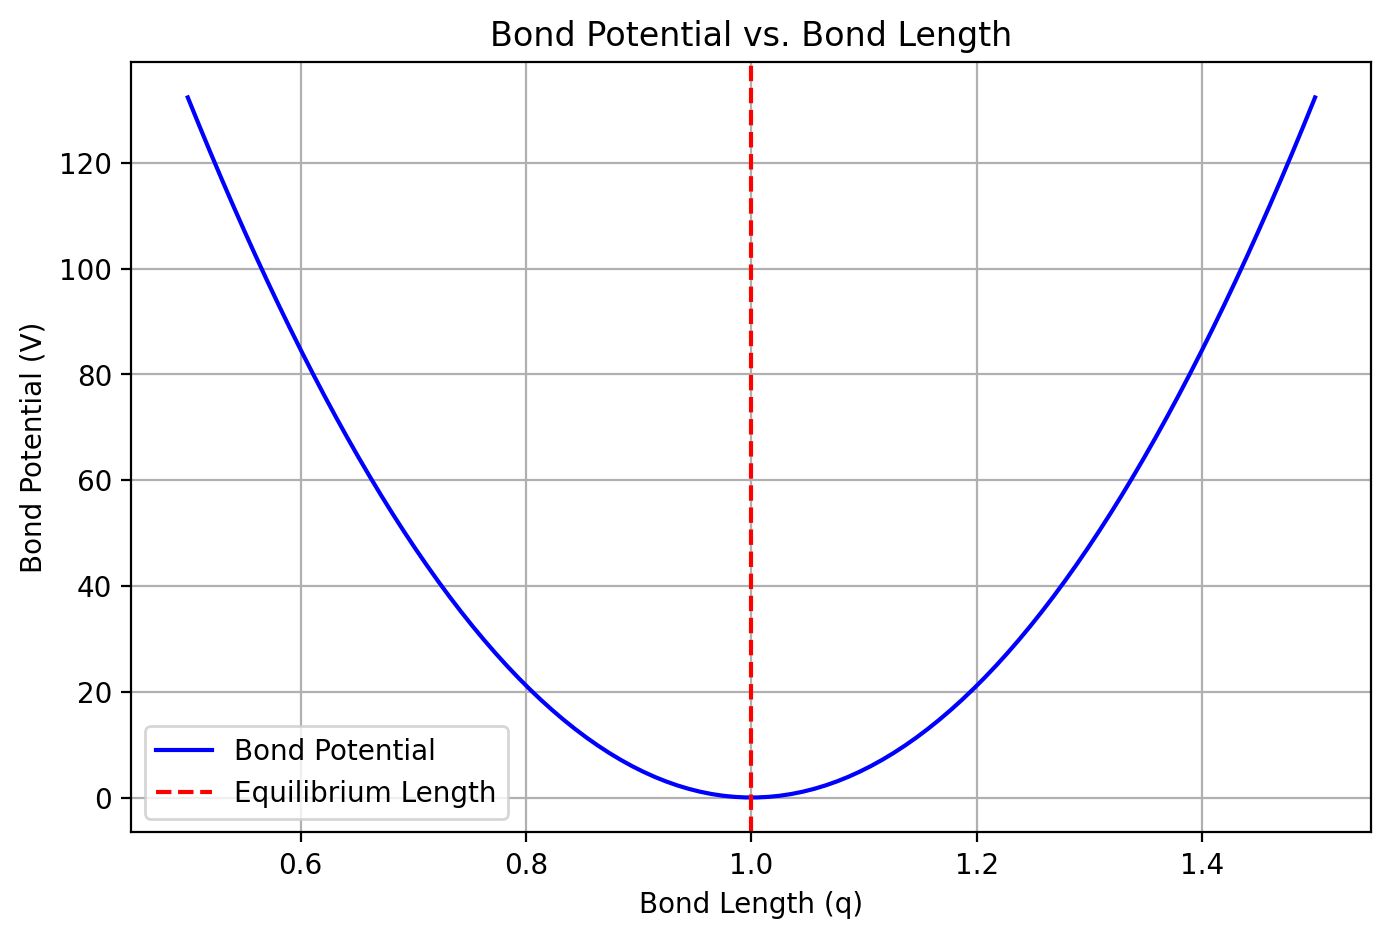

In [1]:
# Let's start by plotting the 1D parabola for a single bond:
import numpy as np
import matplotlib.pyplot as plt 
%config InlineBackend.figure_format = 'retina'

# Parameters
k_bond = 1059.162  # Example value for SPC water
q_eq = 1.0         # Equilibrium bond length

# Bond potential function
def bond_potential(q, k_bond, q_eq):
    return 0.5 * k_bond * (q - q_eq)**2

# Generate bond lengths around the equilibrium
q_values = np.linspace(0.5, 1.5, 100)
v_values = bond_potential(q_values, k_bond, q_eq)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(q_values, v_values, label='Bond Potential', color='blue')
plt.axvline(q_eq, color='red', linestyle='--', label='Equilibrium Length')
plt.title('Bond Potential vs. Bond Length')
plt.xlabel('Bond Length (q)')
plt.ylabel('Bond Potential (V)')
plt.legend()
plt.grid()
plt.show()


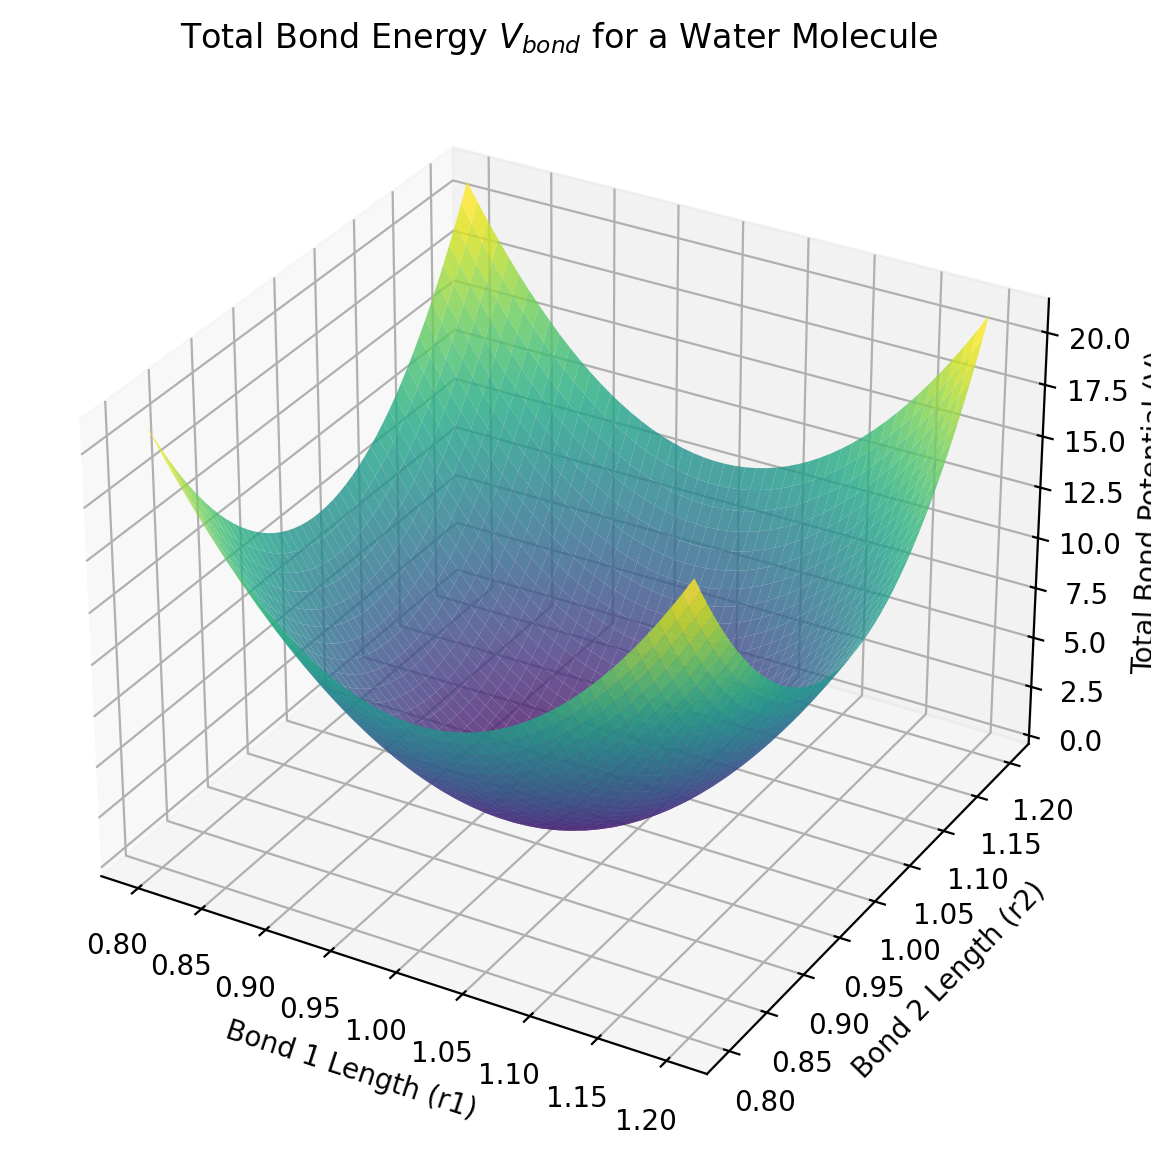

In [8]:
# Combining both H-O bonds, first axis is r1 (the separation between H1 and O), second axis is r2 (the separation between H2 and O), and the z-axis is the total bond potential: the sum.
import numpy as np
import matplotlib.pyplot as plt

k_bond = 1059.162
q_eq = 1.0

# 1. Generate a grid of bond lengths
r_values = np.linspace(0.8, 1.2, 50)
R1, R2 = np.meshgrid(r_values, r_values)

# 2. Calculate the total potential for each combination of bond lengths
V_total = 0.5 * bond_potential(R1, k_bond, q_eq) + 0.5 * bond_potential(R2, k_bond, q_eq)  # Placeholder for total potential

# 3. Plotting the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(R1, R2, V_total, cmap='viridis', alpha=0.8)

ax.set_xlabel('Bond 1 Length (r1)')
ax.set_ylabel('Bond 2 Length (r2)')
ax.set_zlabel('Total Bond Potential (V)')
ax.set_title('Total Bond Energy $V_{bond}$ for a Water Molecule')
plt.show()

## Angle Potential $V_{angle}$

$$V_{angle}\left(q_1, \ldots, q_n\right)  =\frac{1}{2} \sum_{\left(h_1, o, h_2\right) \in \mathcal{M}} k_\theta\left(\theta\left(q_{h_1}, q_o, q_{h_2}\right)-\theta_{e q}\right)^2$$



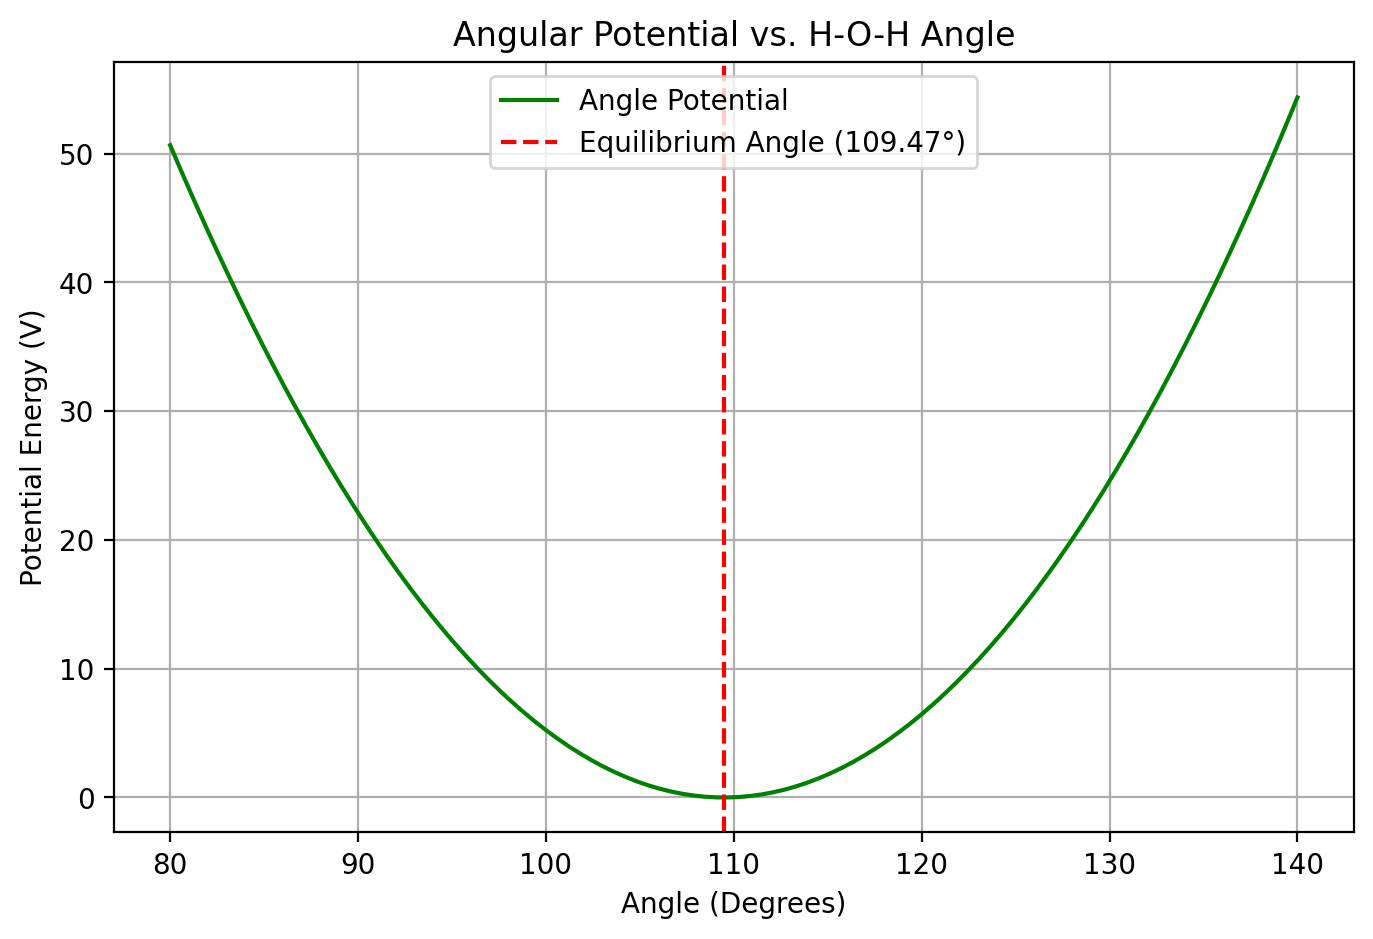

In [9]:
import numpy as np
import matplotlib.pyplot as plt 

# Parameters for SPC Water Angle
# Just for intuition use degrees for the equilibrium angle, but convert to radians for the potential calculation

k_theta = 383.0  # Example angular spring constant
theta_eq_deg = 109.47
theta_eq_rad = np.deg2rad(theta_eq_deg)

def angle_potential(theta_rad, k_theta, theta_eq_rad):
    return 0.5 * k_theta * (theta_rad - theta_eq_rad)**2

# Generate angles from 80 to 140 degrees to see the "bowl"
theta_deg_values = np.linspace(80, 140, 100)
theta_rad_values = np.deg2rad(theta_deg_values)

# Calculate potential
v_angle_values = angle_potential(theta_rad_values, k_theta, theta_eq_rad)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(theta_deg_values, v_angle_values, label='Angle Potential', color='green')
plt.axvline(theta_eq_deg, color='red', linestyle='--', label='Equilibrium Angle (109.47°)')
plt.title('Angular Potential vs. H-O-H Angle')
plt.xlabel('Angle (Degrees)')
plt.ylabel('Potential Energy (V)')
plt.legend()
plt.grid()
plt.show()

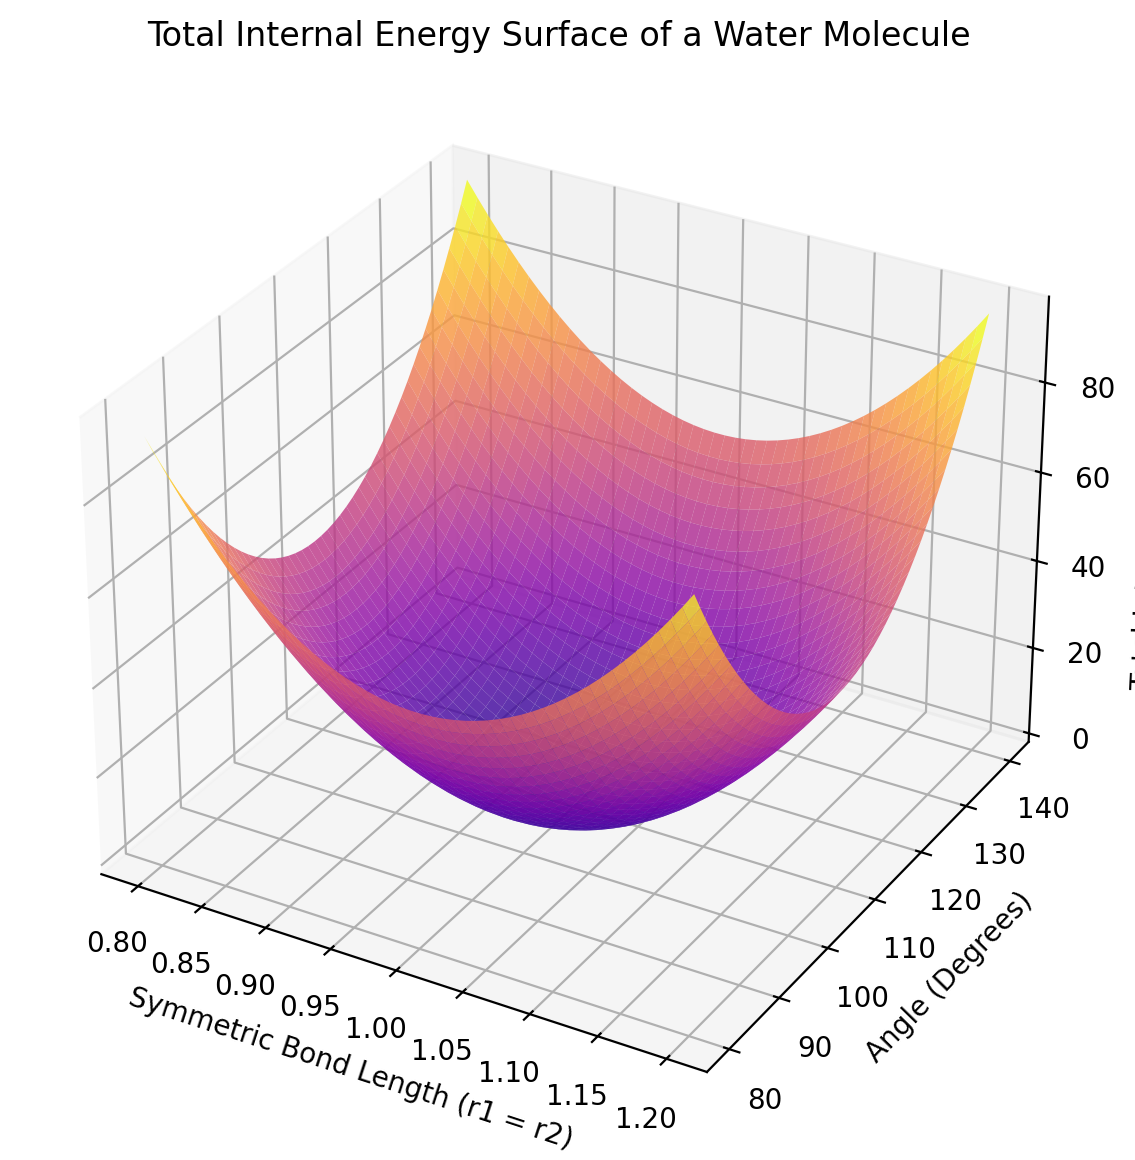

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# For visualizing the total internal potential, we need to consider both the bond lengths and the angle.
# Also, we will assume a symmetric case where r1 = r2 = R for simplicity, and we will vary the angle to see it in 3D plotting.
# Parameters
k_bond = 1059.162
q_eq = 1.0
k_theta = 383.0  
theta_eq_rad = np.deg2rad(109.47)

# 1. Create a grid of Symmetric Bond Lengths (r) and Angles (theta)
r_values = np.linspace(0.8, 1.2, 50)
theta_deg_values = np.linspace(80, 140, 50)
theta_rad_values = np.deg2rad(theta_deg_values)

# Create the 2D grid
R, THETA = np.meshgrid(r_values, theta_rad_values)

# 2. Calculate the Total Potential
# Since r1 = r2 = R, we have TWO bonds contributing to the energy
v_bond_total = 2 * (0.5 * k_bond * (R - q_eq)**2)
v_angle_total = 0.5 * k_theta * (THETA - theta_eq_rad)**2

V_TOTAL = v_bond_total + v_angle_total

# 3. Plotting the 3D Surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(R, np.rad2deg(THETA), V_TOTAL, cmap='plasma', alpha=0.8)

# Labels
ax.set_xlabel('Symmetric Bond Length (r1 = r2)')
ax.set_ylabel('Angle (Degrees)')
ax.set_zlabel('Total Internal Potential (V)')
ax.set_title('Total Internal Energy Surface of a Water Molecule')

plt.show()